Computer Vision Based Disease Classfication

In [2]:
# Install required libraries

!pip install -q kagglehub
!pip install -q scikit-learn
!pip install -q seaborn

# Core Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Image Processing & Utilities
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

In [3]:
import kagglehub
import os

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

print("Raw Dataset Path:", dataset_path)

# Check folder structure
print("Initial Contents:", os.listdir(dataset_path))

# Fix folder level if nested
if "COVID-19_Radiography_Dataset" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "COVID-19_Radiography_Dataset")

print("Final Dataset Path:", dataset_path)
print("Final Contents:", os.listdir(dataset_path))


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Raw Dataset Path: /kaggle/input/covid19-radiography-database
Initial Contents: ['COVID-19_Radiography_Dataset']
Final Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
Final Contents: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']


TensorFlow-Only GPU Check



In [4]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    print("GPU is available and will be used automatically by TensorFlow.")
else:
    print("No GPU detected. Running on CPU.")

TensorFlow Version: 2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and will be used automatically by TensorFlow.



Dataset Path Verification Block


In [5]:

print("Verifying dataset path...\n")
print("Dataset Path:", dataset_path)

# List all items
items = os.listdir(dataset_path)
print("\nAll items inside dataset folder:")
for item in items:
    print(" -", item)

# Detect only directories (class folders)
class_folders = [
    folder for folder in items
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("\nDetected class folders:")
for folder in class_folders:
    print(" -", folder)

print("\nNumber of class folders detected:", len(class_folders))


Verifying dataset path...

Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset

All items inside dataset folder:
 - Lung_Opacity.metadata.xlsx
 - Normal.metadata.xlsx
 - README.md.txt
 - COVID.metadata.xlsx
 - Normal
 - Lung_Opacity
 - Viral Pneumonia.metadata.xlsx
 - Viral Pneumonia
 - COVID

Detected class folders:
 - Normal
 - Lung_Opacity
 - Viral Pneumonia
 - COVID

Number of class folders detected: 4


In [6]:
import os
import shutil

clean_dataset = "/content/xray_dataset"

classes = ["COVID","Normal","Lung_Opacity","Viral Pneumonia"]

os.makedirs(clean_dataset, exist_ok=True)

for cls in classes:
    src = os.path.join(dataset_path, cls, "images")
    dst = os.path.join(clean_dataset, cls)

    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file), dst)

Image Transform / Preprocessing Block

In [7]:
# Minimal TF prep: split + normalize to [0,1] (no extra imports)

img_size = (224, 224)
batch_size = 32
val_split = 0.2
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    clean_dataset,
    validation_split=val_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    clean_dataset,
    validation_split=val_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    color_mode='grayscale'
)

normalizer = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# Keep transform for the downstream torchvision ImageFolder block
transform = None

Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Found 21165 files belonging to 4 classes.
Using 4233 files for validation.


Verify sample images (first 25 from training set)



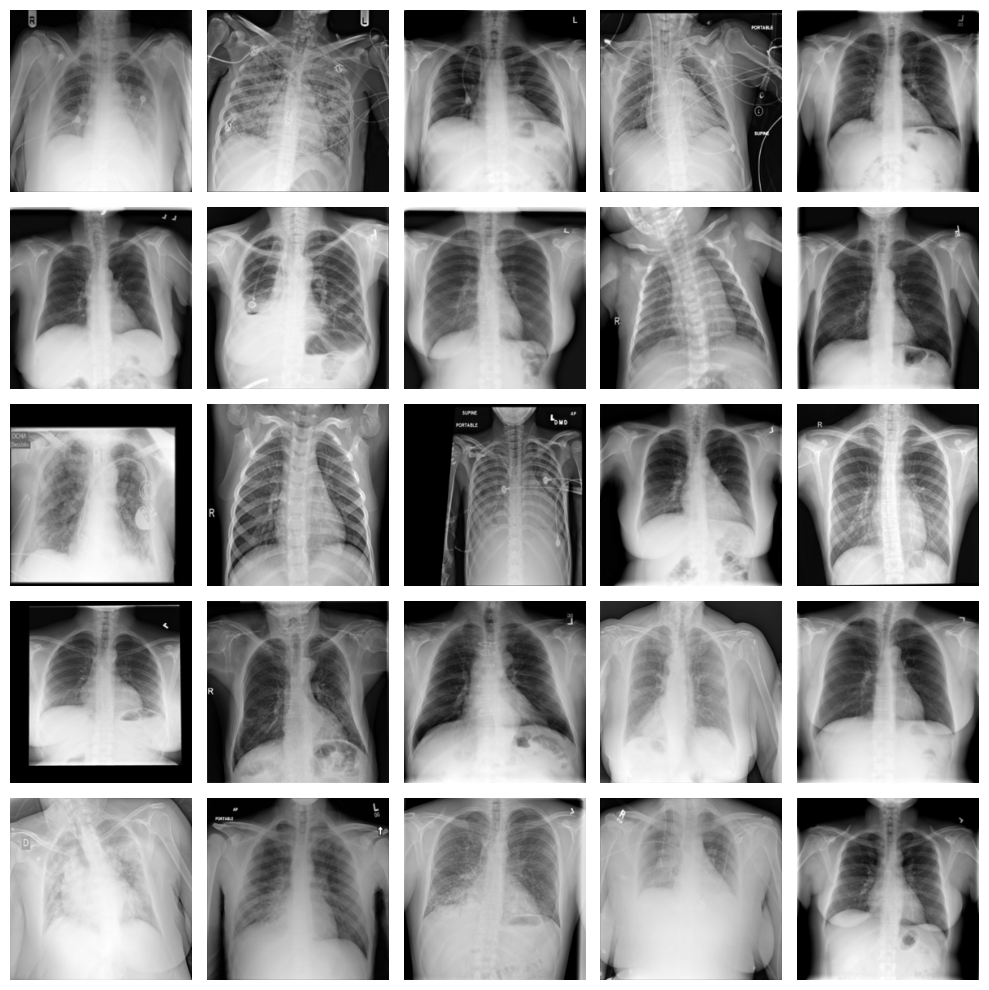

In [8]:
# Get one batch safely
batch_images, batch_labels = next(iter(train_ds))

# If class_names was lost after .map(), define manually
try:
    class_names
except NameError:
    class_names = train_ds.class_names if hasattr(train_ds, "class_names") else None

# Plot first 25 images
plt.figure(figsize=(10, 10))

for i in range(min(25, batch_images.shape[0])):
    ax = plt.subplot(5, 5, i + 1)

    img = batch_images[i].numpy()

    # Handle grayscale properly
    if img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap="gray")
    else:
        plt.imshow(img)

    if class_names is not None:
        label_idx = int(batch_labels[i].numpy())
        plt.title(class_names[label_idx], fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
conv_base = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
conv_base.add(layers.Flatten())
conv_base.add(layers.Dense(128, activation='relu'))
conv_base.add(layers.Dropout(0.5))   # important for medical dataset
conv_base.add(layers.Dense(4, activation='softmax'))

In [12]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,900 (42.61 MB)

 Trainable params: 11,168,900 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
conv_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = conv_base.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 55s 84ms/step - accuracy: 0.6200 - loss: 0.9078 - val_accuracy: 0.7798 - val_loss: 0.5589
Epoch 2/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.7884 - loss: 0.5487 - val_accuracy: 0.8190 - val_loss: 0.4534
Epoch 3/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8318 - loss: 0.4532 - val_accuracy: 0.8490 - val_loss: 0.3825
Epoch 4/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8535 - loss: 0.3796 - val_accuracy: 0.8642 - val_loss: 0.3599
Epoch 5/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8786 - loss: 0.3253 - val_accuracy: 0.8646 - val_loss: 0.3737
Epoch 6/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8956 - loss: 0.2812 - val_accuracy: 0.8694 - val_loss: 0.3767
Epoch 7/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9093 - loss: 0.2446 - val_accuracy: 0.8760 - val_loss: 0.3633
Epoch 8/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9204 - loss: 0.2072 - 

In [14]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

Final Training Accuracy: 0.9656862616539001
Final Validation Accuracy: 0.8927474617958069


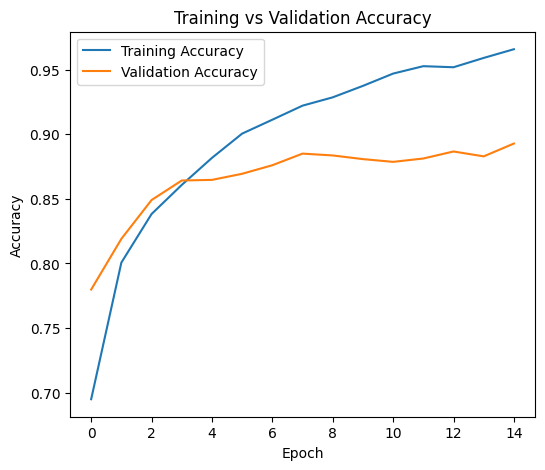

In [15]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(len(acc))

plt.figure(figsize=(6,5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

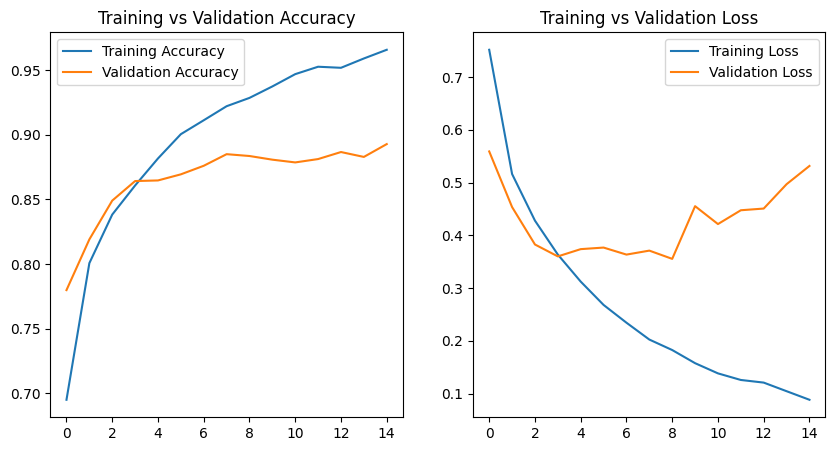

In [16]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

In [18]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = conv_base.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 857ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━

In [19]:
print("Total True Labels:", len(y_true))
print("Total Predictions:", len(y_pred))

print("\nFirst 10 True Labels:")
print(y_true[:10])

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Total True Labels: 4233
Total Predictions: 4233

First 10 True Labels:
[1 1 2 2 1 0 1 2 2 2]

First 10 Predictions:
[2 1 2 2 1 0 1 2 2 2]


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8927474604299551


In [21]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred, average='weighted')
print("Precision:", precision)

Precision: 0.8929744338750008


In [22]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred, average='weighted')
print("Recall:", recall)

Recall: 0.8927474604299551


In [23]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.8925405466514903


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


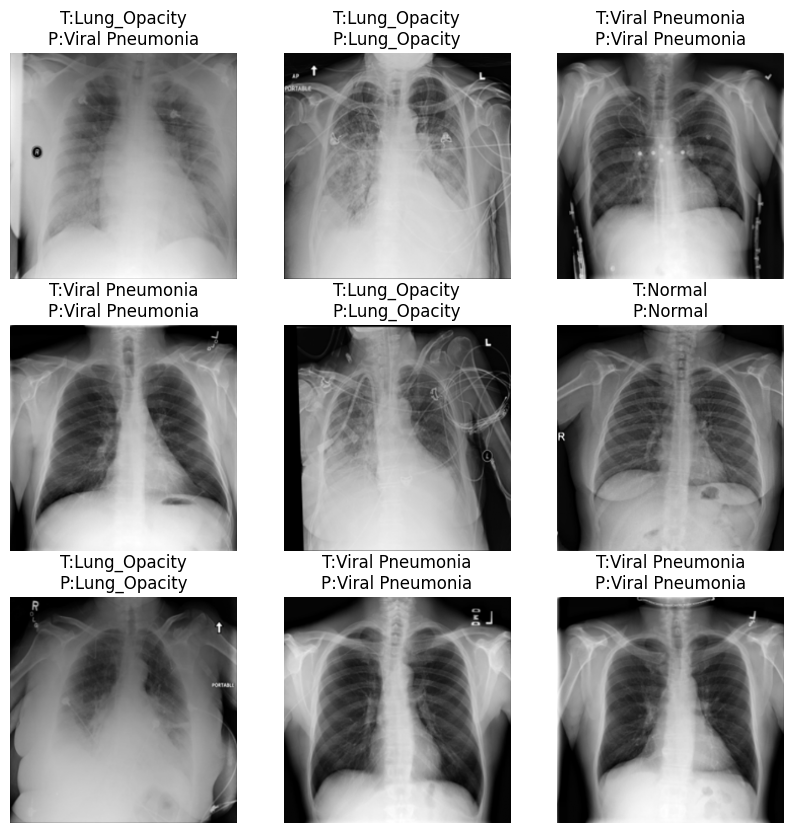

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Use the already existing class_folders variable
class_names = class_folders

plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):

    preds = conv_base.predict(images)
    preds = np.argmax(preds, axis=1)

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        img = images[i].numpy().squeeze()
        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]

        plt.imshow(img, cmap="gray")
        plt.title(f"T:{true_label}\nP:{pred_label}")
        plt.axis("off")

plt.show()

In [34]:
from google.colab import files

uploaded = files.upload()

Saving covid.png to covid.png


In [35]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

def test_model(image_path):

    img = Image.open(image_path).convert("L")
    img = img.resize((224,224))

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = conv_base.predict(img_array)
    probs = predictions[0]

    predicted_class = np.argmax(probs)

    plt.imshow(img, cmap="gray")
    plt.title("Test Image")
    plt.axis("off")
    plt.show()

    print("\nPredicted Disease:", class_names[predicted_class])
    print("Confidence Score:", round(probs[predicted_class]*100,2), "%\n")

    print("Class Probabilities:")
    for i, name in enumerate(class_names):
        print(f"{name}: {probs[i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


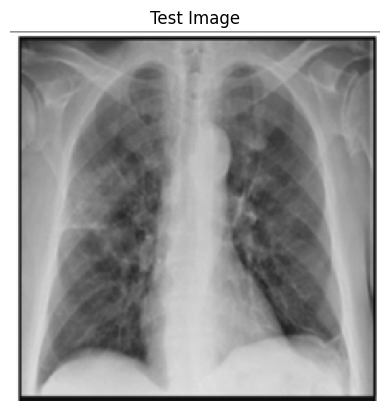


Predicted Disease: Normal
Confidence Score: 100.0 %

Class Probabilities:
Normal: 100.00%
Lung_Opacity: 0.00%
Viral Pneumonia: 0.00%
COVID: 0.00%


In [36]:
for file_name in uploaded.keys():
    test_model(file_name)